In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv('Salary_dataset.csv')

In [3]:
df.head()

,YearsExperience,Salary
0,1.2,393.0
1,1.4,462.0
2,1.6,377.0
3,2.1,435.0
4,2.3,398.0


In [4]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

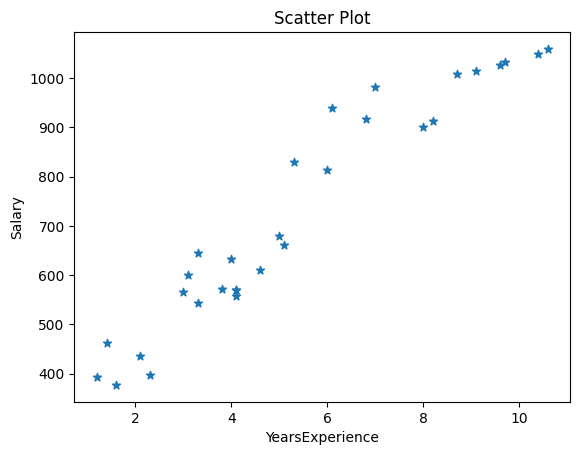

In [5]:
##scatter plot
plt.scatter(df['YearsExperience'],df['Salary'],marker='*')
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Scatter Plot")
plt.show()


In [6]:
## Correlation
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.959871
Salary,0.959871,1.000000


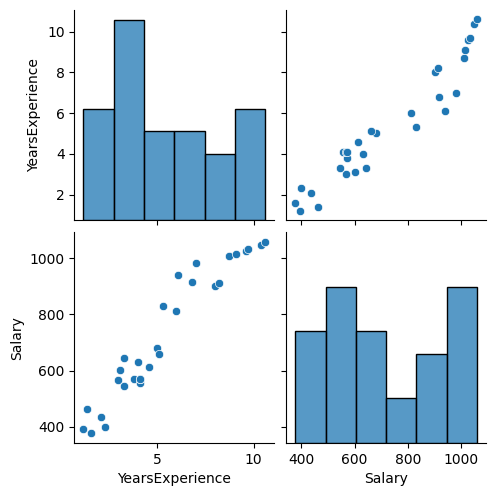

In [7]:
## Seaborn for visulization
import seaborn as sns
sns.pairplot(df)

In [8]:
## Independent and dependent features
X = df[['YearsExperience']]## independent feature should be data frame or 2 dimensional
np.array(X).shape

(30, 1)

In [9]:
X_series = df['YearsExperience']
np.array(X_series).shape

(30,)

In [10]:
y = df['Salary']## This variable can be in series form and 1 dimension


In [11]:
##Train Test Split
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [13]:
X_train.shape

(22, 1)

In [14]:
## Standardization 
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
scaler.fit_transform(X_train)

array([[-0.29001457],
       [-1.37842219],
       [-0.96557792],
       [ 0.0852984 ],
       [-0.70285884],
       [-0.29001457],
       [-0.29001457],
       [ 1.17370602],
       [-1.30335959],
       [-1.228297  ],
       [ 1.58655029],
       [-1.04064051],
       [ 0.79839305],
       [ 1.77420678],
       [ 0.42308008],
       [ 2.14951975],
       [ 0.72333046],
       [-0.59026495],
       [-0.32754587],
       [-0.10235808],
       [ 0.46061137],
       [-0.66532754]])

In [16]:
X_test = scaler.transform(X_test)

In [17]:
X_test

array([[ 1.81173807],
       [ 0.04776711],
       [ 1.24876862],
       [ 0.160361  ],
       [-0.59026495],
       [-0.40260846],
       [ 2.07445715],
       [ 1.4364251 ]])

In [18]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [19]:
Regression = LinearRegression()

In [20]:
Regression.fit(X_train,y_train)

LinearRegression()

In [21]:
print("Coefficient or slop:" ,Regression.coef_)
print("Intercept:",Regression.intercept_)

Coefficient or slop: [80.53037799]
Intercept: 290.642885414605


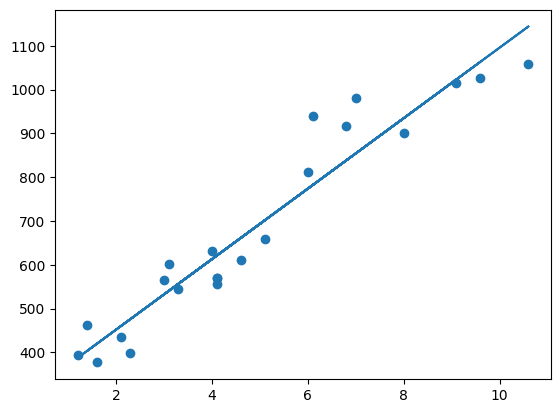

In [22]:
## plot Training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,Regression.predict(X_train))

In [23]:
## predication for test data
y_pred = Regression.predict(X_test)

C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [25]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error : ",mse)
print("Mean Absolute Error : ",mae)
print("Root Mean Squared Error : ",rmse)

Mean Squared Error :  252756.51332475943
Mean Absolute Error :  491.8570396078155
Root Mean Squared Error :  502.7489565625765


In [26]:
from sklearn.metrics import r2_score

In [27]:
score = r2_score(y_test,y_pred)

In [28]:
print(score)

-7.062039047643651


Display adjusted R-squared

In [29]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

-8.405712222250926

OLS  Linear Regression

In [30]:
import statsmodels.api as sm

In [31]:
model = sm.OLS(y_train,X_train).fit()

In [32]:
prediction = model.predict(X_test)

In [33]:
prediction

array([229.09058681,   6.04005314, 157.90424628,  20.27732124,
       -74.63779947, -50.90901929, 262.31087906, 181.63302646])

In [34]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.954
Model:                            OLS   Adj. R-squared (uncentered):              0.952
Method:                 Least Squares   F-statistic:                              440.5
Date:                Tue, 10 Mar 2026   Prob (F-statistic):                    1.43e-15
Time:                        21:22:02   Log-Likelihood:                         -141.93
No. Observations:                  22   AIC:                                      285.9
Df Residuals:                      21   BIC:                                      287.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [36]:
## Prediction for new data
Regression.predict(scaler.transform([[11]]))

C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([475.83416152])

In [37]:
Regression.predict([[11]])

C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1176.47704334])